# Transfer Learning với Dữ liệu Việt Nam
Notebook này thực hiện Fine-Tuning mô hình TFT đã được pre-train trên dữ liệu toàn cầu sang dữ liệu đặc thù của Việt Nam (`vn_tft_ready.csv`).
Các bước chính:
1. Xây dựng TimeSeriesDataSet cho dữ liệu Việt Nam.
2. Load pretrained weights.
3. Đóng băng (Freeze) một số lớp mạng nếu cần, và huấn luyện tiếp (Fine-tune).
4. Đánh giá kết quả bằng các chỉ số RMSE, MAE, MAPE và trực quan hóa dự báo.


In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, shutil, copy
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# PyTorch 2.6 defaults torch.load(weights_only=True); allowlist trusted classes used in checkpoints.
torch.serialization.add_safe_globals([GroupNormalizer, QuantileLoss])

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'.')
VN_DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
PRETRAIN_CKPT  = BASE_DIR / 'checkpoint' / 'tft_v3_best.ckpt'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'tft_vn_v3'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data : {VN_DATA_PATH}')
print(f'Pretrain: {PRETRAIN_CKPT}')
print(f'Exists  : {PRETRAIN_CKPT.exists()}')

PyTorch : 2.9.1+cu126
Device  : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
VN data : data\processed\VN_data\vn_tft_ready.csv
Pretrain: checkpoint\tft_v3_best.ckpt
Exists  : True


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Điều chỉnh cho VN dataset)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    # VN chỉ có 72 tháng → encoder 12 (không thể 24 như source)
    max_encoder_length    = 18,   # 18 tháng lịch sử
    max_prediction_length = 6,    # dự báo 6 tháng
    min_series_length     = 24,   # 18 + 6

    # ── Economic Variables ────────────────────────────────────────────────────
    economic_vars = [
        'IPI_Value', 'CPI_Value', 'GDP_trillion', 'Oil_Price',
        'FDI_disbursed', 'gas_price', 'castlecoal_price'
    ],

    # ── Split: dùng 2024 (12 tháng cuối) làm test ─────────────────────────────
    val_cutoff_months     = 12,

    # ── Model — giữ nguyên kiến trúc từ pretrained ────────────────────────────
    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.2,  # tăng nhẹ để regularize (VN data nhỏ)
    hidden_continuous_size= 32,
    lstm_layers           = 2,
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── Phase 1: Frozen LSTM — chỉ train VSN + head ───────────────────────────
    phase1_lr             = 1e-3,
    phase1_epochs         = 15,
    phase1_patience       = 8,

    # ── Phase 2: Full fine-tune với LR rất nhỏ ───────────────────────────────
    phase2_lr             = 1e-5,  # 10x nhỏ hơn phase1
    phase2_epochs         = 20,
    phase2_patience       = 10,
    weight_decay          = 1e-4,
    phase2_warmup_epochs  = 3,

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size            = 16,   # nhỏ hơn vì dataset nhỏ
    gradient_clip_val     = 0.5,
    num_workers           = 0,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config VN Transfer Learning:')
for k, v in CFG.items():
    print(f'  {k:<28}: {v}')

INFO: Seed set to 42


[11:04:24] INFO     Seed set to 42                                   seed.py:57
Config VN Transfer Learning:
  max_encoder_length          : 18
  max_prediction_length       : 6
  min_series_length           : 24
  economic_vars               : ['IPI_Value', 'CPI_Value', 'GDP_trillion', 'Oil_Price', 'FDI_disbursed', 'gas_price', 'castlecoal_price']
  val_cutoff_months           : 12
  hidden_size                 : 128
  attention_head_size         : 4
  dropout                     : 0.2
  hidden_continuous_size      : 32
  lstm_layers                 : 2
  loss_quantiles              : [0.1, 0.25, 0.5, 0.75, 0.9]
  phase1_lr                   : 0.001
  phase1_epochs               : 15
  phase1_patience             : 8
  phase2_lr                   : 1e-05
  phase2_epochs               : 20
  phase2_patience             : 10
  weight_decay                : 0.0001
  phase2_warmup_epochs        : 3
  batch_size                  : 16
  gradient_clip_val           : 0.5
  num_workers       

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')
print(f'Series      : {sorted(df["series"].unique())}')

# ── Loại Other fossil (73% zeros, CV=2.45 — không học được) ──────────────────
FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()
print(f'After filter: {df.shape} — Series: {sorted(df["series"].unique())}')

# ── Tạo prec_zscore (bị thiếu trong file VN) ─────────────────────────────────
mu  = df.groupby('entity')['precipitation'].transform('mean')
std = df.groupby('entity')['precipitation'].transform('std').replace(0, 1)
df['prec_zscore'] = (df['precipitation'] - mu) / std
print('prec_zscore: created')

# ── Đảm bảo time_idx liên tục ─────────────────────────────────────────────────
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

# ── Xử lý NaN (điền khuyết) ───────────────────────────────────────────────────
# Do NaN xuất hiện ở đầu chuỗi (2019-01), dùng interpolate + bfill cho từng group
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df.groupby(['entity', 'series'])[num_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# ── Check ─────────────────────────────────────────────────────────────────────
nan_counts = df.isnull().sum()
print(f'Total NaN: {nan_counts.sum()}')
if nan_counts.sum() > 0:
    print(f'Remaining NaNs in: {nan_counts[nan_counts > 0].index.tolist()}')

# ── Tạo Lag-1 cho các biến kinh tế (Tránh leak) ──────────────────────────────
print(f"Lagging economic variables: {CFG['economic_vars']}")
for var in CFG['economic_vars']:
    df[var] = df.groupby(['entity', 'series'])[var].shift(1)

# Xử lý NaN sau khi shift (điền giá trị tháng đầu bằng giá trị hiện tại hoặc bfill)
df[CFG['economic_vars']] = df.groupby(['entity', 'series'])[CFG['economic_vars']].transform(lambda x: x.bfill())

print(f'Date: {df["date"].min().date()} -> {df["date"].max().date()}')
print()
print('Serie lengths:')
for s, g in df.groupby('series'):
    print(f'  {s}: {len(g)} months, time_idx=[{g["time_idx"].min()},{g["time_idx"].max()}]')


Raw VN shape: (432, 30)
Series      : ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']
After filter: (360, 30) — Series: ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
prec_zscore: created
Total NaN: 0
Lagging economic variables: ['IPI_Value', 'CPI_Value', 'GDP_trillion', 'Oil_Price', 'FDI_disbursed', 'gas_price', 'castlecoal_price']
Date: 2019-01-01 -> 2024-12-01

Serie lengths:
  Coal: 72 months, time_idx=[0,71]
  Gas: 72 months, time_idx=[0,71]
  Hydro: 72 months, time_idx=[0,71]
  Solar: 72 months, time_idx=[0,71]
  Wind: 72 months, time_idx=[0,71]


Correlation with target (generation_TWh) after shifting:


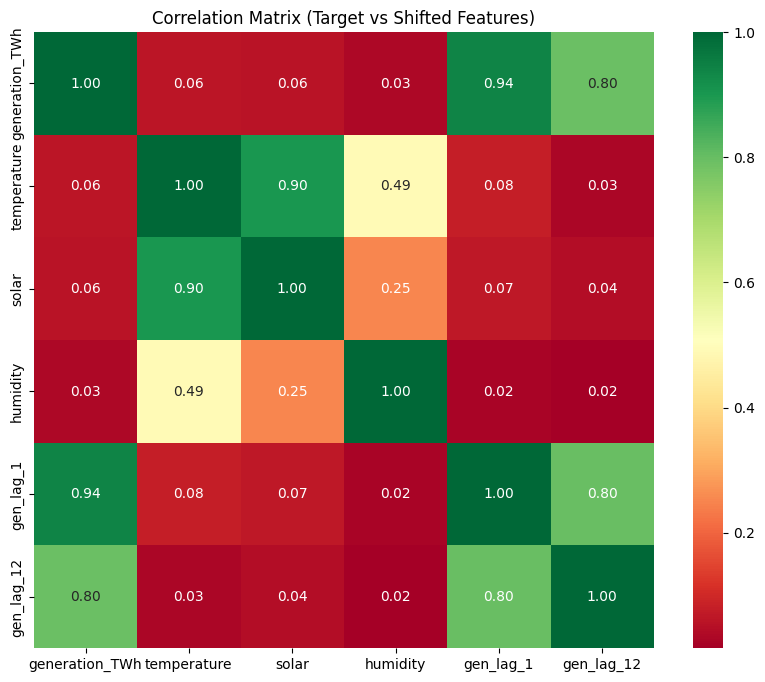


Top correlations with Target:
generation_TWh    1.000000
gen_lag_1         0.940735
gen_lag_12        0.795338
temperature       0.058962
solar             0.055001
humidity          0.031471
Name: generation_TWh, dtype: float64


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3.1 — KIỂM TRA ĐỘ TƯƠNG QUAN (Leakage Audit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# import seaborn as sns

# print("Correlation with target (generation_TWh) after shifting:")
# features_to_check = [
#     'generation_TWh', 'temperature', 'solar', 'humidity',
#     'gen_lag_1', 'gen_lag_12', 'temp_anomaly', 'solar_norm'
# ]
# corr_matrix = df[features_to_check].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
# plt.title("Correlation Matrix (Target vs Shifted Features)")
# plt.show()

# print("\nTop correlations with Target:")
# print(corr_matrix['generation_TWh'].sort_values(ascending=False))
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3.1 — KIỂM TRA ĐỘ TƯƠNG QUAN (Leakage Audit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import seaborn as sns

print("Correlation with target (generation_TWh) after shifting:")
features_to_check = [
    col for col in [
        'generation_TWh', 'temperature', 'solar', 'humidity',
        'gen_lag_1', 'gen_lag_12', 'temp_anomaly', 'solar_norm'
    ] if col in df.columns
]

corr_matrix = df[features_to_check].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation Matrix (Target vs Shifted Features)")
plt.show()

print("\nTop correlations with Target:")
print(corr_matrix['generation_TWh'].sort_values(ascending=False))

Correlation with target (generation_TWh) after shifting:


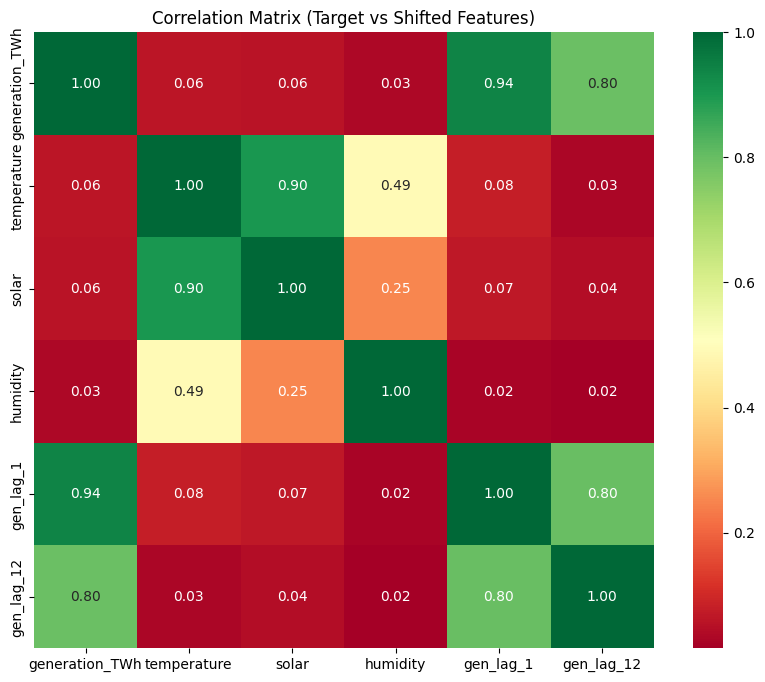


Top correlations with Target:
generation_TWh    1.000000
gen_lag_1         0.940735
gen_lag_12        0.795338
temperature       0.058962
solar             0.055001
humidity          0.031471
Name: generation_TWh, dtype: float64


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3.1 — KIỂM TRA ĐỘ TƯƠNG QUAN (Leakage Audit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# import seaborn as sns

# print("Correlation with target (generation_TWh) after shifting:")
# features_to_check = [
#     'generation_TWh', 'temperature', 'solar', 'humidity',
#     'gen_lag_1', 'gen_lag_12', 'temp_anomaly', 'solar_norm'
# ]
# corr_matrix = df[features_to_check].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
# plt.title("Correlation Matrix (Target vs Shifted Features)")
# plt.show()

# print("\nTop correlations with Target:")
# print(corr_matrix['generation_TWh'].sort_values(ascending=False))
import seaborn as sns

print("Correlation with target (generation_TWh) after shifting:")

features_to_check = [col for col in ['generation_TWh', 'temperature', 'solar', 'humidity', 'gen_lag_1', 'gen_lag_12', 'temp_anomaly', 'solar_norm'] if col in df.columns]

corr_matrix = df[features_to_check].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation Matrix (Target vs Shifted Features)")
plt.show()

print("\nTop correlations with Target:")
print(corr_matrix['generation_TWh'].sort_values(ascending=False))

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TimeSeriesDataSet (dùng cùng feature mapping với pretrained model)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# QUAN TRỌNG: known/unknown_reals phải KHỚP HOÀN TOÀN với source model
# Thêm VN-specific features vào unknown_reals (model sẽ học thêm từ đây)
STATIC_CATEGORICALS = ['entity']

# TIME_VARYING_KNOWN_REALS = [
#     'time_idx',
#     'month', 'month_sin', 'month_cos', 'quarter', 'year',
#     # VN extra known (lịch vạn niên, mùa vụ - biết trước 100%)
#     'is_dry_season',    # mùa khô/mưa VN
#     'is_flood_season',  # mùa lũ miền Bắc/Trung
#     'quarter_sin',
#     'quarter_cos',
# ]

# TIME_VARYING_UNKNOWN_REALS = [
#     # ── Weather (CHUYỂN SANG UNKNOWN VÌ LÀ QUAN TRẮC QUÁ KHỨ) ────────────────
#     'temperature',
#     'solar',
#     'humidity',
#     'precipitation',
#     'log_precipitation',
#     'prec_zscore',
#     'temp_anomaly',
#     'solar_norm',
#     'humidity_anomaly',
#     'prec_lag_1',
#     'prec_lag_2',
#     'precip_roll6',
# ]

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'is_dry_season', 'is_flood_season',
    'quarter_sin', 'quarter_cos',
]

TIME_VARYING_UNKNOWN_REALS = [
    'temperature', 'solar', 'humidity', 'precipitation',
    'log_precipitation', 'prec_zscore', 'temp_anomaly', 'solar_norm',
    'humidity_anomaly', 'prec_lag_1', 'prec_lag_2', 'precip_roll6',
]

# Nếu cột rolling 6 tháng chưa có thì dùng cột hiện có để tránh lỗi KeyError
if 'precip_roll6' not in df.columns and 'prec_roll_3' in df.columns:
    df['precip_roll6'] = df['prec_roll_3']

# Loại duplicate
# TIME_VARYING_UNKNOWN_REALS = list(dict.fromkeys(TIME_VARYING_UNKNOWN_REALS + CFG['economic_vars']))
TIME_VARYING_UNKNOWN_REALS = list(dict.fromkeys(TIME_VARYING_UNKNOWN_REALS + CFG['economic_vars']))

# ── LỌC CHỈ GIỮ CỘT THỰC SỰ TỒN TẠI ─────────────────────────────────────────
TIME_VARYING_KNOWN_REALS   = [c for c in TIME_VARYING_KNOWN_REALS   if c in df.columns]
TIME_VARYING_UNKNOWN_REALS = [c for c in TIME_VARYING_UNKNOWN_REALS if c in df.columns]

print("Known reals :", TIME_VARYING_KNOWN_REALS)
print("Unknown reals:", TIME_VARYING_UNKNOWN_REALS)

# Kiểm tra columns tồn tại
all_needed = (STATIC_CATEGORICALS + TIME_VARYING_KNOWN_REALS +
              TIME_VARYING_UNKNOWN_REALS + ['series'])
missing = [c for c in all_needed if c not in df.columns]
if missing:
    print(f'Missing cols: {missing}')
else:
    print('All columns OK!')

# ── Train/Val split ───────────────────────────────────────────────────────────
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])
print(f'Training cutoff time_idx: {training_cutoff} (date ~ {val_cutoff_date.date()})')
print(f'Train/Val rows: {(df["time_idx"]<=training_cutoff).sum()} / {(df["time_idx"]>training_cutoff).sum()}')

# ── Tạo datasets ──────────────────────────────────────────────────────────────
print('\nCreating TimeSeriesDataSet...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Training samples  : {len(training_vn):,}')
print(f'Validation samples: {len(validation_vn):,}')

Known reals : ['time_idx', 'month', 'year']
Unknown reals: ['temperature', 'solar', 'humidity', 'precipitation', 'prec_zscore', 'precip_roll6', 'IPI_Value', 'CPI_Value', 'GDP_trillion', 'Oil_Price', 'FDI_disbursed', 'gas_price', 'castlecoal_price']
All columns OK!
Training cutoff time_idx: 59 (date ~ 2023-12-01)
Train/Val rows: 300 / 60

Creating TimeSeriesDataSet...
Training samples  : 325
Validation samples: 5


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 4, num_workers=CFG['num_workers']
)

x, y = next(iter(train_loader))
print('DataLoaders OK')
print(f'  Encoder : {x["encoder_cont"].shape}')
print(f'  Decoder : {x["decoder_cont"].shape}')
print(f'  Target  : {y[0].shape}')
print(f'  Train batches: {len(train_loader)}')

DataLoaders OK
  Encoder : torch.Size([16, 18, 20])
  Decoder : torch.Size([16, 6, 20])
  Target  : torch.Size([16, 6])
  Train batches: 20


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — TẠO MODEL TFT CHO VN & COPY PRETRAINED WEIGHTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Tạo model mới từ VN dataset (có nhiều features hơn source)
vn_model = TemporalFusionTransformer.from_dataset(
    training_vn,
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    learning_rate          = CFG['phase1_lr'],
    optimizer              = 'adamw',
    log_interval           = 5,
)

n_params_vn = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'VN model parameters: {n_params_vn:,} ({n_params_vn/1e6:.2f}M)')

# ── Load pretrained weights (partial transfer) ────────────────────────────────
if PRETRAIN_CKPT.exists():
    pretrained_ckpt = torch.load(str(PRETRAIN_CKPT), map_location='cpu', weights_only=False)
    pretrained_state = pretrained_ckpt['state_dict']

    vn_state = vn_model.state_dict()
    transferred, skipped = [], []

    for name, param in pretrained_state.items():
        if name in vn_state:
            if vn_state[name].shape == param.shape:
                vn_state[name].copy_(param)
                transferred.append(name)
            else:
                skipped.append(f'{name}: shape {param.shape} -> {vn_state[name].shape}')
        else:
            skipped.append(f'{name}: not in VN model')

    vn_model.load_state_dict(vn_state)
    print(f'\nTransferred weights : {len(transferred)}')
    print(f'Skipped (shape diff): {len(skipped)}')
    if skipped[:5]:
        print('  Sample skipped:', skipped[:5])
else:
    print(f'Pretrained checkpoint not found: {PRETRAIN_CKPT}')
    print('Training from scratch...')

VN model parameters: 1,370,772 (1.37M)

Transferred weights : 338
Skipped (shape diff): 126
  Sample skipped: ['input_embeddings.embeddings.entity.weight: shape torch.Size([20, 9]) -> torch.Size([1, 1])', 'input_embeddings.embeddings.series.weight: shape torch.Size([9, 5]) -> torch.Size([5, 4])', 'prescalers.month_sin.weight: not in VN model', 'prescalers.month_sin.bias: not in VN model', 'prescalers.month_cos.weight: not in VN model']


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: FREEZE LSTM + ATTENTION, TRAIN CHỈ VSN + HEAD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def freeze_encoder_layers(model):
    """Freeze LSTM encoder và multi-head attention."""
    frozen = []
    for name, param in model.named_parameters():
        # Freeze: LSTM encoder, multi-head attention
        if any(keyword in name for keyword in
               ['lstm_encoder', 'multihead_attn', 'self_attn',
                'encoder_lstm', 'attention']):
            param.requires_grad = False
            frozen.append(name)
    return frozen

def unfreeze_all(model):
    """Unfreeze tất cả parameters."""
    for param in model.parameters():
        param.requires_grad = True

# Freeze encoder
frozen_layers = freeze_encoder_layers(vn_model)
trainable_p1 = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
total_params  = sum(p.numel() for p in vn_model.parameters())

print(f'Phase 1 — Frozen LSTM + Attention layers:')
print(f'  Frozen layers    : {len(frozen_layers)}')
print(f'  Trainable params : {trainable_p1:,} / {total_params:,} ({trainable_p1/total_params*100:.1f}%)')

# Update learning rate cho phase 1
vn_model.hparams.learning_rate = CFG['phase1_lr']

# Callbacks Phase 1
ckpt_p1 = ModelCheckpoint(
    dirpath=str(CKPT_DIR), filename='vn_phase1_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, save_last=False
)
es_p1 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase1_patience'], mode='min', verbose=True
)

# FP16/bf16 có thể gây lỗi ScalarType BFloat16 trong một số op,
# nên dùng 32-bit để đảm bảo tương thích.
train_precision = '32'

trainer_p1 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase1_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p1, es_p1],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase1'),
    enable_progress_bar = True,
    precision         = train_precision,
)

print(f'\nPhase 1 Training: LR={CFG["phase1_lr"]}, epochs={CFG["phase1_epochs"]}, patience={CFG["phase1_patience"]}')
print('=' * 60)

# IMPORTANT: tránh lỗi "cudnn RNN backward can only be called in training mode"
vn_model.train()
if hasattr(vn_model, "lstm_encoder"):
    vn_model.lstm_encoder.train()
if hasattr(vn_model, "lstm_decoder"):
    vn_model.lstm_decoder.train()

trainer_p1.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 1 done! Best val_loss = {ckpt_p1.best_model_score:.6f}')

Phase 1 — Frozen LSTM + Attention layers:
  Frozen layers    : 27
  Trainable params : 1,065,332 / 1,370,772 (77.7%)


INFO: GPU available: True (cuda), used: True


[11:04:26] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

INFO: Metric val_loss improved by 0.155 >= min_delta = 0.0. New best score: 0.491


[11:05:09] INFO     Metric val_loss improved by 0.155 >=  early_stopping.py:305
                    min_delta = 0.0. New best score:                           
                    0.491                                                      


INFO: `Trainer.fit` stopped: `max_epochs=15` reached.


[11:05:32] INFO     `Trainer.fit` stopped: `max_epochs=15`      fit_loop.py:192
                    reached.                                                   



Phase 1 done! Best val_loss = 0.490762


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: UNFREEZE + FULL FINE-TUNE VỚI LR NHỎ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load best Phase 1 checkpoint
best_p1_path = ckpt_p1.best_model_path
with torch.serialization.safe_globals([GroupNormalizer, QuantileLoss]):
    vn_model_p2  = TemporalFusionTransformer.load_from_checkpoint(best_p1_path)

# Unfreeze toàn bộ
unfreeze_all(vn_model_p2)
trainable_p2 = sum(p.numel() for p in vn_model_p2.parameters() if p.requires_grad)
print(f'Phase 2 — Full fine-tune:')
print(f'  Trainable params: {trainable_p2:,} (100%)')

# Update LR cho phase 2 (rất nhỏ để không phá pretrained weights)
vn_model_p2.hparams.learning_rate = CFG['phase2_lr']

# Callbacks Phase 2
ckpt_p2 = ModelCheckpoint(
    dirpath  = str(CKPT_DIR),
    filename = 'tft_vn_v3_{epoch:02d}_{val_loss:.4f}',
    monitor  = 'val_loss',
    mode     = 'min',
    save_top_k = 3,
    save_last  = True,
    verbose    = True,
)
es_p2 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase2_patience'], mode='min', verbose=True
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# FP16 có thể gây lỗi overflow với mask bias lớn trong attention của TFT.
# Dùng 32-bit để train ổn định, tránh RuntimeError: at::Half overflow.
trainer_p2 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase2_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p2, es_p2, lr_monitor],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase2'),
    enable_progress_bar = True,
    precision         = '32',
)

print(f'\nPhase 2 Training: LR={CFG["phase2_lr"]}, epochs={CFG["phase2_epochs"]}, patience={CFG["phase2_patience"]}')
print('=' * 60)

# Giữ model ở training mode để tránh lỗi cuDNN RNN backward trong một số môi trường
vn_model_p2.train()
if hasattr(vn_model_p2, "lstm_encoder"):
    vn_model_p2.lstm_encoder.train()
if hasattr(vn_model_p2, "lstm_decoder"):
    vn_model_p2.lstm_decoder.train()

trainer_p2.fit(vn_model_p2, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 2 done! Best val_loss = {ckpt_p2.best_model_score:.6f}')
print(f'Best checkpoint  : {ckpt_p2.best_model_path}')

INFO: GPU available: True (cuda), used: True


Phase 2 — Full fine-tune:
  Trainable params: 1,370,772 (100%)
[11:05:34] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.518. Signaling Trainer to stop.


[11:06:19] INFO     Monitored metric val_loss did not     early_stopping.py:305
                    improve in the last 10 records. Best                       
                    score: 0.518. Signaling Trainer to                         
                    stop.                                                      


INFO: Epoch 10, global step 220: 'val_loss' was not in top 3


           INFO     Epoch 10, global step 220:          model_checkpoint.py:936
                    'val_loss' was not in top 3                                



Phase 2 done! Best val_loss = 0.517829
Best checkpoint  : D:\WorkSpace\Study\NCKH\checkpoint\tft_vn_v3_epoch=00_val_loss=0.5178.ckpt


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — LƯU CHECKPOINT CUỐI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL_CKPT   = CKPT_DIR / 'tft_vn_v3_best.ckpt'
FINAL_LATEST = CKPT_DIR / 'tft_vn_v3_latest.ckpt'

if os.path.exists(ckpt_p2.best_model_path):
    shutil.copy2(ckpt_p2.best_model_path, FINAL_CKPT)
    print(f'Best  -> {FINAL_CKPT}')
if os.path.exists(ckpt_p2.last_model_path):
    shutil.copy2(ckpt_p2.last_model_path, FINAL_LATEST)
    print(f'Latest-> {FINAL_LATEST}')

# Config JSON
vn_config = {
    'version'                   : 'tft_vn_v3',
    'pretrained_from'           : str(PRETRAIN_CKPT),
    'best_ckpt'                 : str(FINAL_CKPT),
    'best_val_loss'             : float(ckpt_p2.best_model_score),
    'phase1_val_loss'           : float(ckpt_p1.best_model_score),
    'fine_tune_series'          : FINE_TUNE_SERIES,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus)',
    'hidden_size'               : CFG['hidden_size'],
    'phase1_lr'                 : CFG['phase1_lr'],
    'phase2_lr'                 : CFG['phase2_lr'],
    'static_categoricals'       : STATIC_CATEGORICALS,
    'time_varying_known_reals'  : TIME_VARYING_KNOWN_REALS,
    'time_varying_unknown_reals': TIME_VARYING_UNKNOWN_REALS,
}

cfg_path = CKPT_DIR / 'tft_vn_v3_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(vn_config, f, indent=2, ensure_ascii=False)
print(f'Config -> {cfg_path}')

Best  -> checkpoint\tft_vn_v3_best.ckpt
Latest-> checkpoint\tft_vn_v3_latest.ckpt
Config -> checkpoint\tft_vn_v3_config.json


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — EVALUATION: METRICS TỔNG QUÁT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with torch.serialization.safe_globals([GroupNormalizer, QuantileLoss]):
    best_vn = TemporalFusionTransformer.load_from_checkpoint(str(FINAL_CKPT))
best_vn.eval()
print(f'Loaded: {FINAL_CKPT.name}')

raw_preds = best_vn.predict(val_loader, mode='raw', return_x=True)
point_preds = best_vn.predict(val_loader, mode='prediction', return_x=True)
pred_vals, x_vals = point_preds.output, point_preds.x

actuals = torch.cat([y[0] for _, y in val_loader])

mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2*(actuals - pred_vals).abs() /
         (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = ((actuals - pred_vals).abs().sum() /
         (actuals.abs().sum() + 1e-8)).item() * 100

ss_res = ((actuals - pred_vals) ** 2).sum()
ss_tot = ((actuals - actuals.mean()) ** 2).sum()
r2 = (1 - ss_res / (ss_tot + 1e-8)).item()

print(f'\nValidation Metrics — VN Fine-tuned Model (2024):')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  R2    : {r2:.4f}')
print(f'  SMAPE : {smape:.2f}%')
print(f'  WAPE  : {wape:.2f}%')

INFO: GPU available: True (cuda), used: True


Loaded: tft_vn_v3_best.ckpt
[11:06:21] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61

Validation Metrics — VN Fine-tuned Model (2024):
  MAE   : 0.7607 TWh
  RMSE  : 0.9828 TWh
  R2    : 0.9548
  SMAPE : 19.77%
  WAPE  : 14.25%


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — METRICS THEO TỪNG SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
preds_idx = best_vn.predict(
    val_loader, mode='prediction', return_index=True, return_decoder_lengths=True
)

results = []
pred_out = preds_idx.output
pred_index = preds_idx.index

for i in range(len(pred_out)):
    row  = pred_index.iloc[i]
    ser  = row.get('series', 'unknown')
    results.append({'series': ser, 'pred_mean': float(pred_out[i].mean())})

df_res = pd.DataFrame(results)
print('Series count in predictions:')
print(df_res['series'].value_counts())

print()
print('Target series metrics summary (from overall):')
print(f'  MAE  = {mae:.4f} TWh')
print(f'  RMSE = {rmse:.4f} TWh')
print(f'  WAPE = {wape:.2f}%')

INFO: GPU available: True (cuda), used: True


[11:06:22] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61
Series count in predictions:
series
Coal     1
Gas      1
Hydro    1
Solar    1
Wind     1
Name: count, dtype: int64

Target series metrics summary (from overall):
  MAE  = 0.7607 TWh
  RMSE = 0.9828 TWh
  WAPE = 14.25%


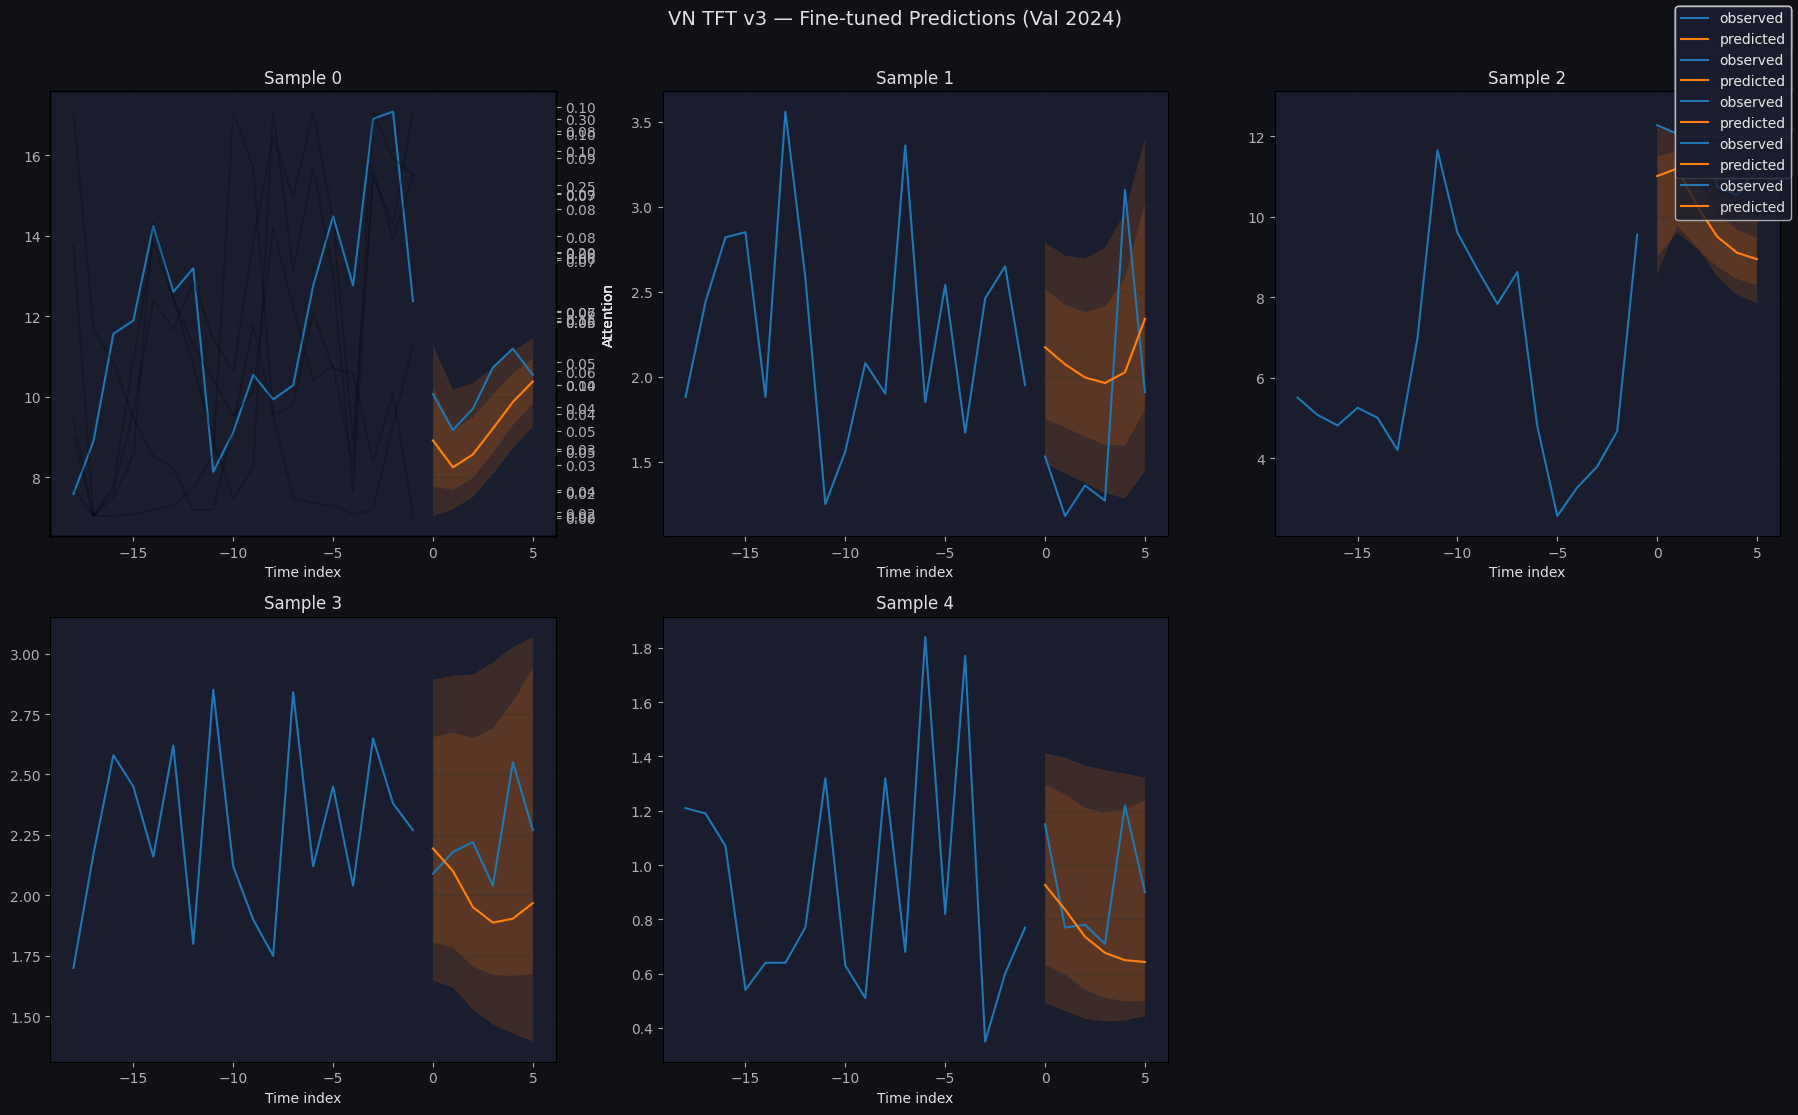

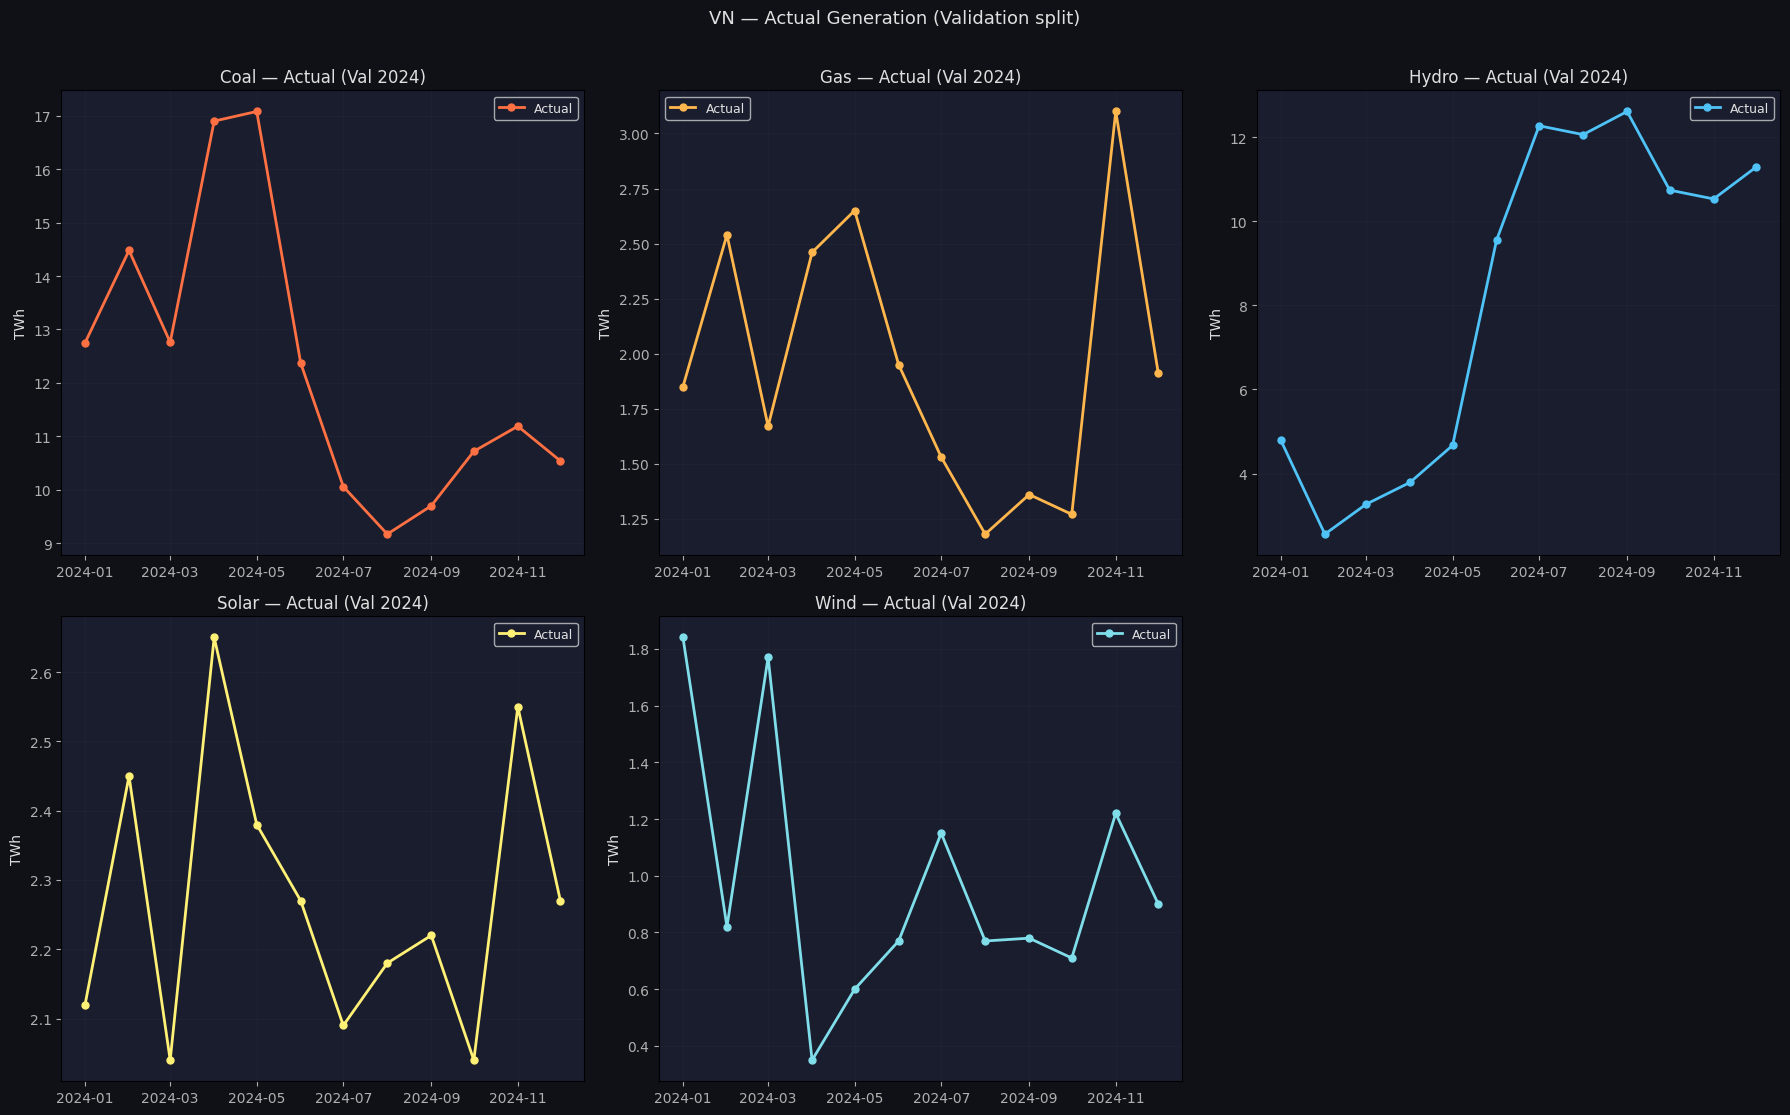

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — VISUALIZE PREDICTIONS PER SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3e', 'grid.alpha': 0.5,
})

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d', 'Hydro': '#4fc3f7',
    'Solar': '#fff176', 'Wind': '#80deea',
}

# Plot 5 prediction samples (1 per series)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, ax in enumerate(axes.flatten()):
    try:
        best_vn.plot_prediction(raw_preds.x, raw_preds.output, idx=i, ax=ax)
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('VN TFT v3 — Fine-tuned Predictions (Val 2024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Actual vs Predicted line plot per series
df_val = df[df['time_idx'] > training_cutoff].copy()
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ser in enumerate(FINE_TUNE_SERIES):
    ax = axes[i]
    sub = df_val[df_val['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')
    ax.plot(sub['date'], sub['generation_TWh'], 'o-', color=color,
            linewidth=2, markersize=5, label='Actual')
    ax.set_title(f'{ser} — Actual (Val 2024)')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[5].set_visible(False)
plt.suptitle('VN — Actual Generation (Validation split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

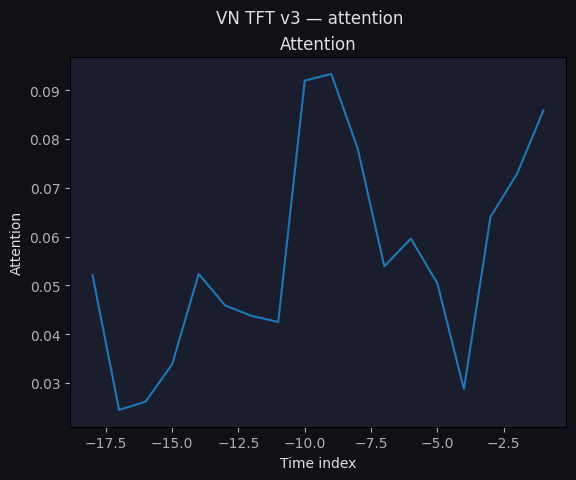

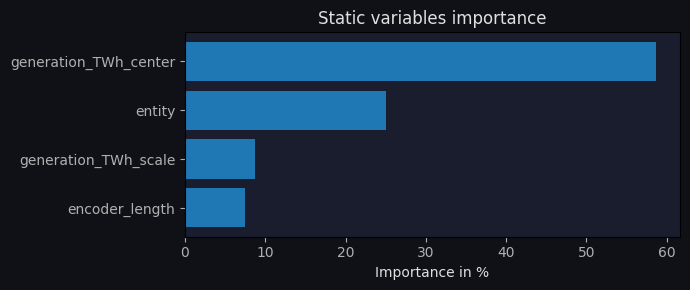

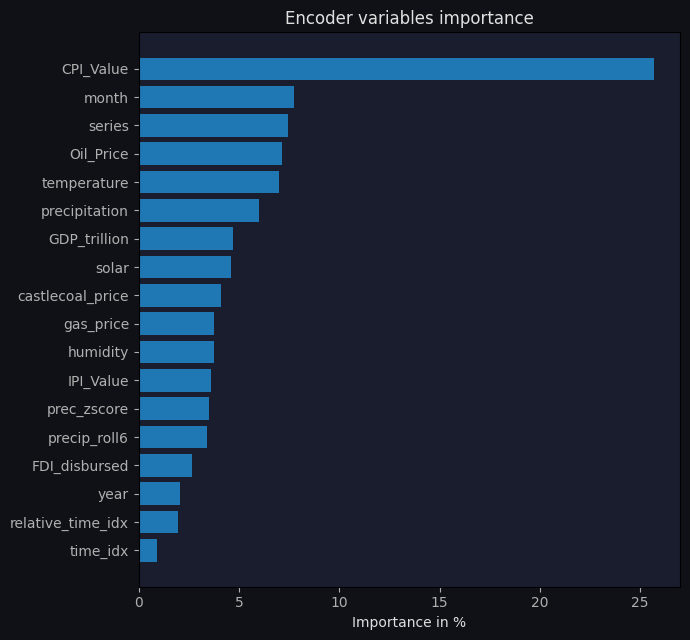

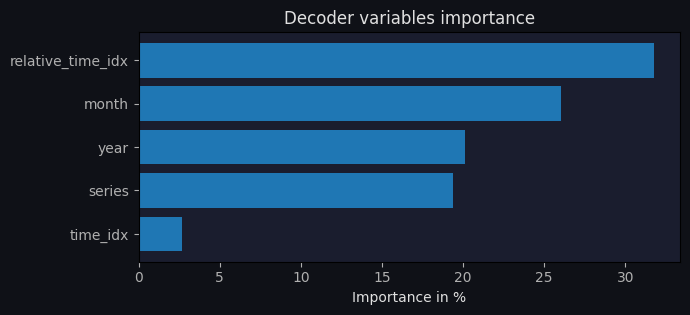

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Top Encoder Variables:
  precip_roll6                        : 1.2849
  generation_TWh_scale                : 0.3863
  encoder_length                      : 0.3726
  CPI_Value                           : 0.3576
  year                                : 0.3509
  solar                               : 0.3004
  IPI_Value                           : 0.2342
  relative_time_idx                   : 0.2296
  FDI_disbursed                       : 0.2057
  Oil_Price                           : 0.1882


In [15]:
# CELL 13 — VARIABLE IMPORTANCE
interpretation = best_vn.interpret_output(raw_preds.output, reduction='sum')
figs = best_vn.plot_interpretation(interpretation)
for title, fig in figs.items():
    if hasattr(fig, 'suptitle'):
        fig.suptitle(f'VN TFT v3 — {title}', fontsize=12)
        plt.tight_layout()
        plt.show()

print('Top Encoder Variables:')
enc = interpretation.get('encoder_variables')
if enc is not None:
    names = training_vn.reals

    # Safe conversion for both CPU/GPU tensors and numpy arrays
    if hasattr(enc, 'detach'):
        enc_vals = enc.detach().cpu().numpy()
    else:
        enc_vals = np.asarray(enc)

    enc_vals = np.ravel(enc_vals)
    imp = pd.Series(enc_vals, index=names[:len(enc_vals)])
    top10 = imp.sort_values(ascending=False).head(10)
    for feat, val in top10.items():
        print(f'  {feat:<35} : {val:.4f}')
else:
    print('No encoder variable importance found in interpretation output.')

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — TỔNG KẾT TRANSFER LEARNING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*65)
print('  KET QUA TRANSFER LEARNING — VN TFT v3')
print('='*65)
print(f'  Pretrained source : tft_v3_best.ckpt (20 quoc gia)')
print(f'  Fine-tune data    : VN 2019-2024 ({len(FINE_TUNE_SERIES)} series)')
print(f'  Phase 1 val_loss  : {ckpt_p1.best_model_score:.6f} (frozen LSTM)')
print(f'  Phase 2 val_loss  : {ckpt_p2.best_model_score:.6f} (full tune)')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  SMAPE : {smape:.2f}%')
print(f'  WAPE  : {wape:.2f}%')
print('='*65)
print(f'  Checkpoint: {FINAL_CKPT}')
print(f'  Config    : {cfg_path}')
print('='*65)
print()
print('Goi y cai thien them:')
print('  1. Neu WAPE > 20%: tang phase2_epochs, giam phase2_lr xuong 1e-5')
print('  2. Neu Wind/Solar RMSE cao: them gen_lag_6 vao unknown_reals')
print('  3. Xem Variable Importance: neu economic features quan trong -> them data')
print('  4. Ko nen fine-tune Other fossil (73% zeros, khong hoc duoc)')

  KET QUA TRANSFER LEARNING — VN TFT v3
  Pretrained source : tft_v3_best.ckpt (20 quoc gia)
  Fine-tune data    : VN 2019-2024 (5 series)
  Phase 1 val_loss  : 0.490762 (frozen LSTM)
  Phase 2 val_loss  : 0.517829 (full tune)
  MAE   : 0.7607 TWh
  RMSE  : 0.9828 TWh
  SMAPE : 19.77%
  WAPE  : 14.25%
  Checkpoint: checkpoint\tft_vn_v3_best.ckpt
  Config    : checkpoint\tft_vn_v3_config.json

Goi y cai thien them:
  1. Neu WAPE > 20%: tang phase2_epochs, giam phase2_lr xuong 1e-5
  2. Neu Wind/Solar RMSE cao: them gen_lag_6 vao unknown_reals
  3. Xem Variable Importance: neu economic features quan trong -> them data
  4. Ko nen fine-tune Other fossil (73% zeros, khong hoc duoc)


INFO: GPU available: True (cuda), used: True


[11:06:26] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


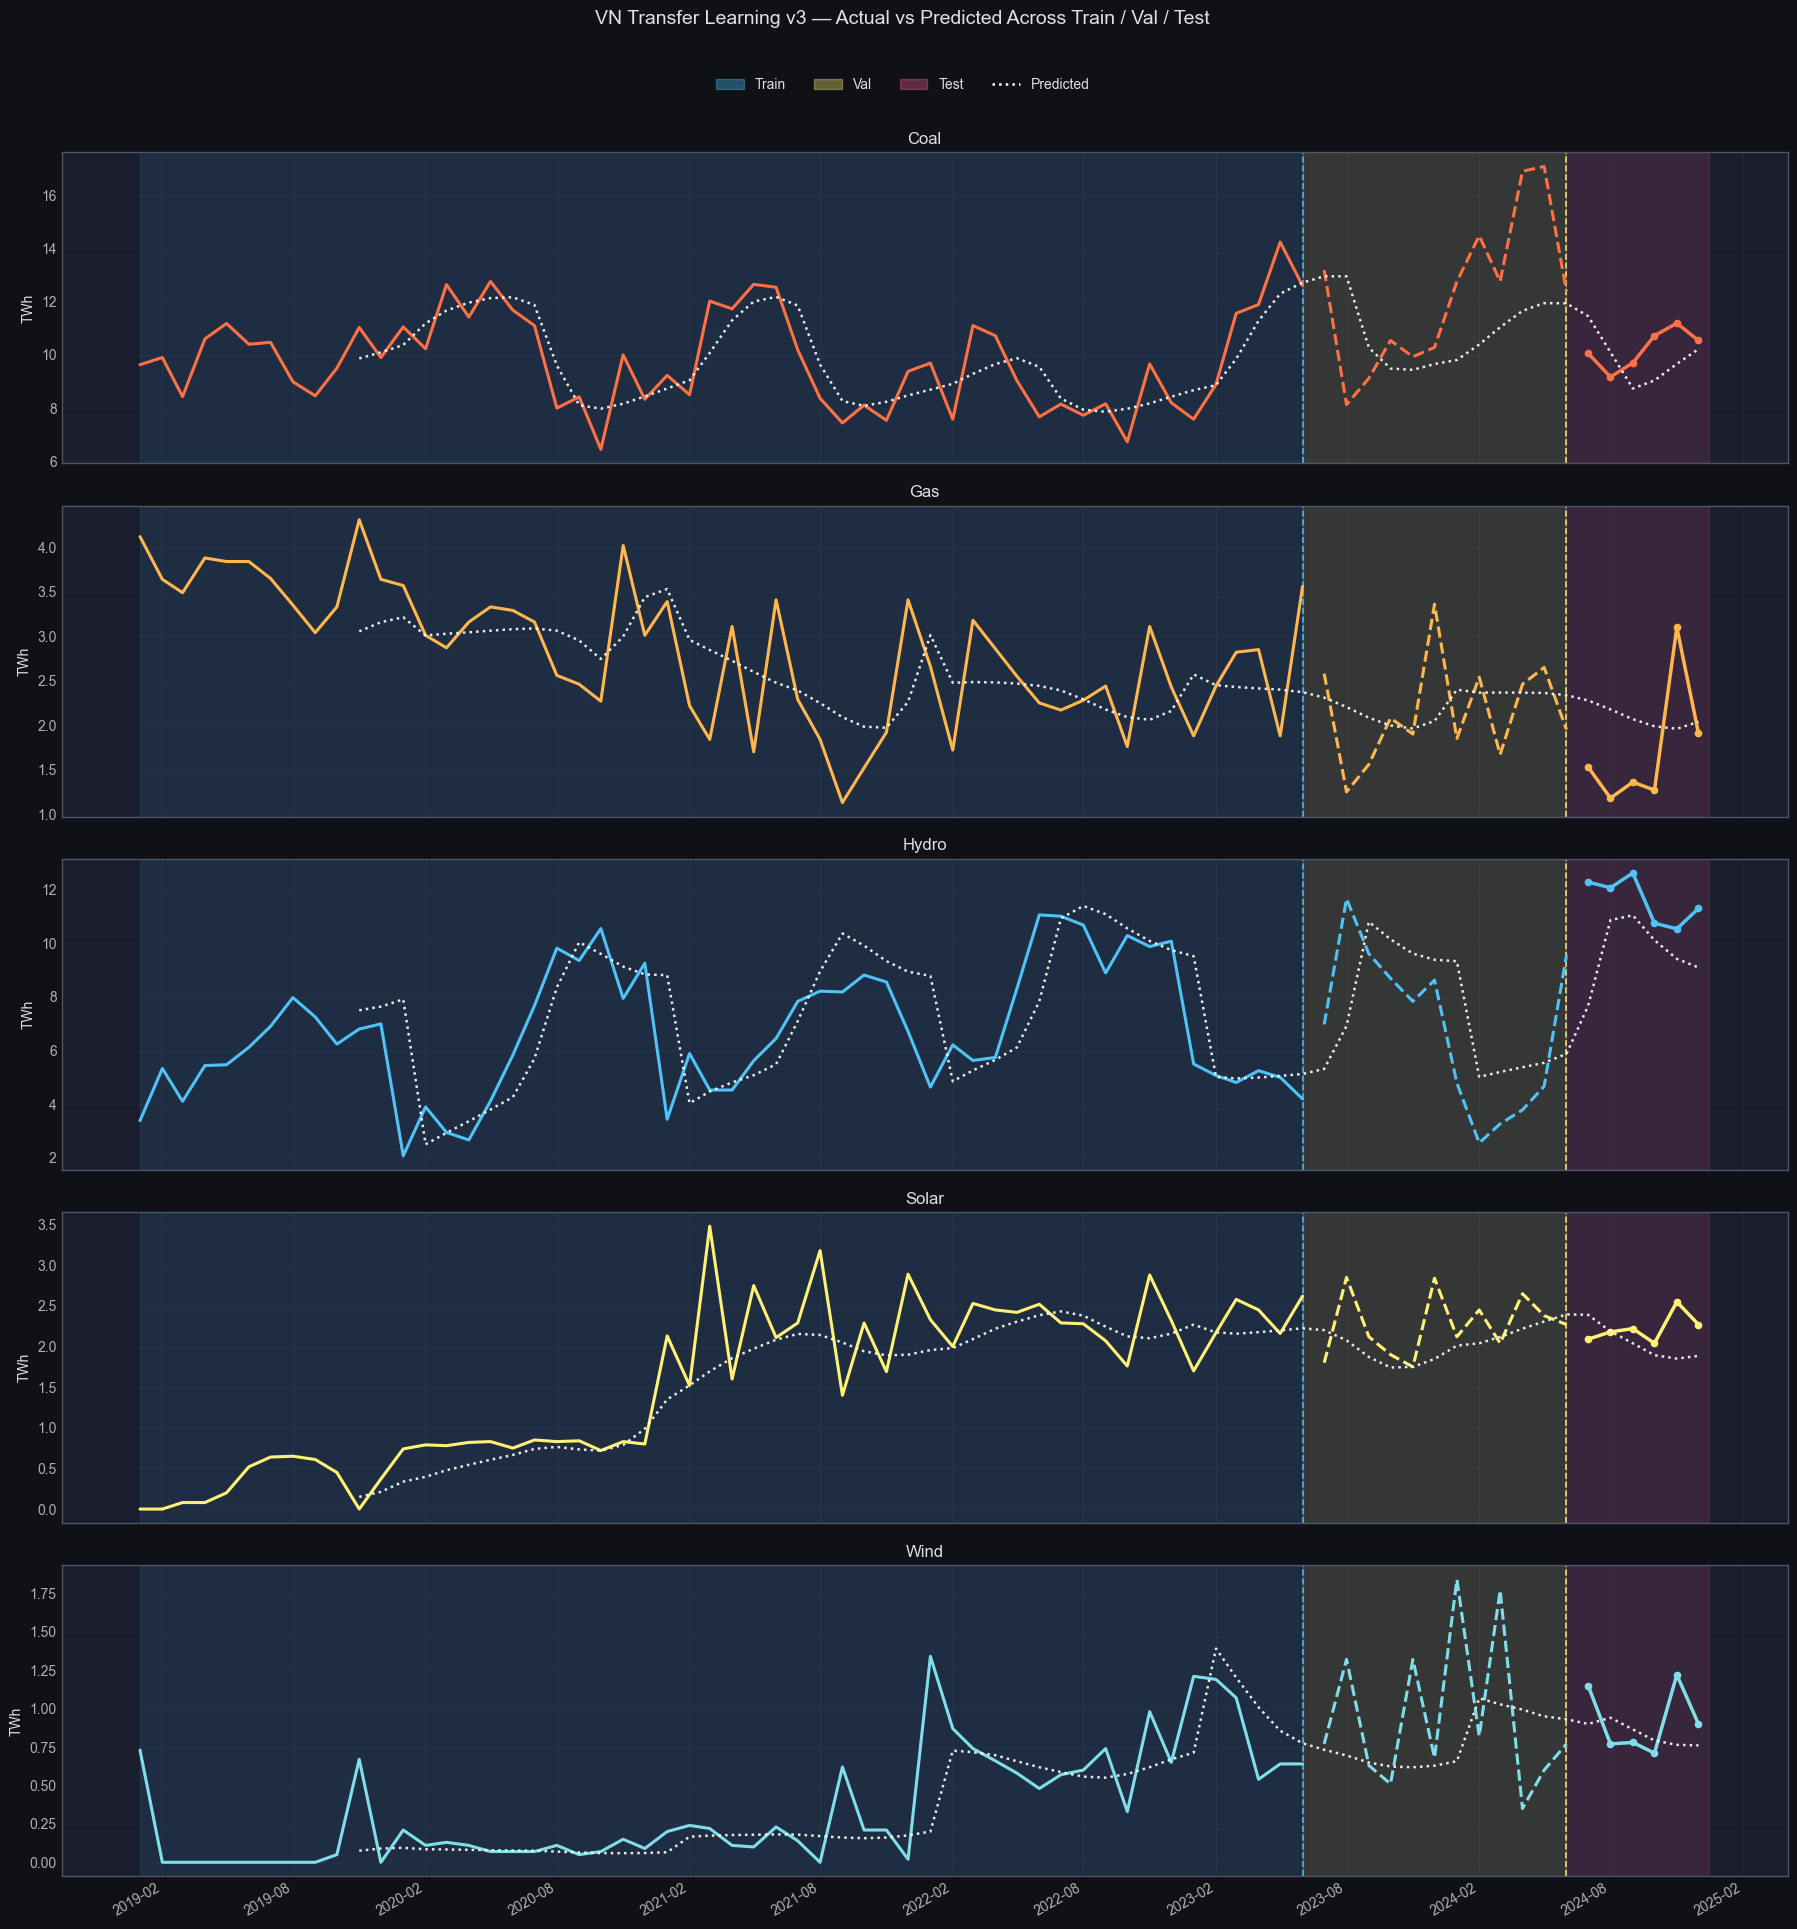

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — VISUALIZE PREDICTIONS PER SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#4d5566',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3e',
    'grid.alpha': 0.5,
})

series_colors = {
    'Coal': '#ff7043',
    'Gas': '#ffb74d',
    'Hydro': '#4fc3f7',
    'Solar': '#fff176',
    'Wind': '#80deea',
}

source_df = globals().get('df')
if source_df is None:
    vn_data_path = globals().get('VN_DATA_PATH')
    if vn_data_path is None:
        vn_data_path = Path('data/processed/VN_data/vn_tft_ready.csv')
    source_df = pd.read_csv(vn_data_path)
source_df = source_df.copy()
source_df['date'] = pd.to_datetime(source_df['date'])

plot_series_all = list(globals().get('FINE_TUNE_SERIES', []))
if not plot_series_all:
    plot_series_all = [ser for ser in source_df['series'].dropna().unique() if ser != 'Other fossil']

train_end = pd.Timestamp(globals().get('TRAIN_END', source_df['date'].max() - pd.DateOffset(months=18)))
val_end = pd.Timestamp(globals().get('VAL_END', source_df['date'].max() - pd.DateOffset(months=6)))
test_end = pd.Timestamp(globals().get('TEST_END', source_df['date'].max()))

# Build a full rolling prediction table over the entire dataset.
full_pred_df = pd.DataFrame()
full_prediction_dataset = None
full_prediction_loader = None

if 'training_vn' in globals():
    try:
        # use the full dataframe and let the dataset generate rolling windows
        # so the resulting forecast can be aligned to the full date span
        full_prediction_dataset = TimeSeriesDataSet.from_dataset(
            training_vn,
            source_df,
            predict=False,
            stop_randomization=True,
        )
        full_prediction_loader = full_prediction_dataset.to_dataloader(
            train=False,
            batch_size=CFG.get('batch_size', 32) * 4,
            num_workers=CFG.get('num_workers', 0),
        )
        full_preds = best_vn.predict(full_prediction_loader, mode='prediction', return_index=True, return_decoder_lengths=True)
        full_pred_out = full_preds.output
        full_pred_index = full_preds.index

        rows = []
        for i, meta in full_pred_index.reset_index(drop=True).iterrows():
            entity_name = meta.get('entity', None)
            series_name = meta.get('series', None)
            start_time_idx = int(meta.get('time_idx', 0))
            pred_row = np.asarray(full_pred_out[i]).reshape(-1)
            horizon = len(pred_row)
            time_row = np.arange(start_time_idx + 1, start_time_idx + 1 + horizon)

            for step, (ti, pred_val) in enumerate(zip(time_row, pred_row), start=1):
                rows.append({
                    'entity': entity_name,
                    'series': series_name,
                    'time_idx': int(ti),
                    'horizon': step,
                    'pred': float(pred_val),
                })

        full_pred_df = pd.DataFrame(rows)
        if not full_pred_df.empty:
            full_pred_df = full_pred_df.merge(
                source_df[['entity', 'series', 'time_idx', 'date', 'generation_TWh']],
                on=['entity', 'series', 'time_idx'],
                how='left',
            )
            full_pred_df['date'] = pd.to_datetime(full_pred_df['date'])
    except Exception:
        full_pred_df = pd.DataFrame()

# Fallback to the last-window prediction table if rolling full predictions are unavailable.
if full_pred_df.empty:
    fallback_df = pd.DataFrame()
    pred_index_obj = globals().get('pred_index')
    pred_out_obj = globals().get('pred_out')
    x_vals_obj = globals().get('x_vals')
    if pred_index_obj is not None and pred_out_obj is not None and x_vals_obj is not None:
        pred_index_df = pred_index_obj.copy()
        decoder_time_idx = np.asarray(x_vals_obj.get('decoder_time_idx')) if isinstance(x_vals_obj, dict) and 'decoder_time_idx' in x_vals_obj else None
        decoder_target = np.asarray(x_vals_obj.get('decoder_target')) if isinstance(x_vals_obj, dict) and 'decoder_target' in x_vals_obj else None
        pred_array = np.asarray(pred_out_obj)

        rows = []
        for i, meta in pred_index_df.reset_index(drop=True).iterrows():
            series_name = meta.get('series', None)
            entity_name = meta.get('entity', None)
            pred_row = np.asarray(pred_array[i]).reshape(-1)
            if decoder_time_idx is not None:
                time_row = np.asarray(decoder_time_idx[i]).reshape(-1)
            else:
                time_row = np.arange(len(pred_row)) + int(meta.get('time_idx', 0)) + 1
            if decoder_target is not None:
                actual_row = np.asarray(decoder_target[i]).reshape(-1)
            else:
                actual_row = [np.nan] * len(pred_row)

            for step, (ti, actual_val, pred_val) in enumerate(zip(time_row, actual_row, pred_row), start=1):
                rows.append({
                    'entity': entity_name,
                    'series': series_name,
                    'time_idx': int(ti),
                    'horizon': step,
                    'actual': float(actual_val) if pd.notna(actual_val) else np.nan,
                    'pred': float(pred_val),
                })

        fallback_df = pd.DataFrame(rows)
        fallback_df = fallback_df.merge(
            source_df[['entity', 'series', 'time_idx', 'date']],
            on=['entity', 'series', 'time_idx'],
            how='left',
        )
        fallback_df['date'] = pd.to_datetime(fallback_df['date'])

    full_pred_df = fallback_df

if full_pred_df.empty:
    raise RuntimeError('No prediction dataframe available for plotting.')

if 'entity' in source_df.columns and source_df['entity'].nunique() > 1:
    base_df = source_df[source_df['entity'] == source_df['entity'].iloc[0]].copy()
else:
    base_df = source_df.copy()

if 'series' in full_pred_df.columns:
    plot_series = [ser for ser in plot_series_all if ser in set(full_pred_df['series'].dropna().unique())]
else:
    plot_series = plot_series_all

fig, axes = plt.subplots(len(plot_series), 1, figsize=(18, 3.7 * len(plot_series)), sharex=True)
if len(plot_series) == 1:
    axes = [axes]

for ax, ser in zip(axes, plot_series):
    color = series_colors.get(ser, '#aaa')
    sub = base_df[base_df['series'] == ser].sort_values('date').copy()
    pred_sub = full_pred_df[full_pred_df['series'] == ser].sort_values('date').copy()

    ax.axvspan(sub['date'].min(), train_end, alpha=0.10, color='#4fc3f7')
    ax.axvspan(train_end, val_end, alpha=0.12, color='#fff176')
    ax.axvspan(val_end, test_end + pd.DateOffset(days=15), alpha=0.14, color='#f06292')
    ax.axvline(train_end, color='#4fc3f7', linewidth=1.2, linestyle='--', alpha=0.9)
    ax.axvline(val_end, color='#fff176', linewidth=1.2, linestyle='--', alpha=0.9)

    train_sub = sub[sub['date'] <= train_end]
    val_sub = sub[(sub['date'] > train_end) & (sub['date'] <= val_end)]
    test_sub = sub[sub['date'] > val_end]

    ax.plot(train_sub['date'], train_sub['generation_TWh'], color=color, linewidth=2.2, label='Train (Actual)')
    ax.plot(val_sub['date'], val_sub['generation_TWh'], color=color, linewidth=2.2, linestyle='--', label='Val (Actual)')
    ax.plot(test_sub['date'], test_sub['generation_TWh'], color=color, linewidth=2.5, marker='o', markersize=4.5, label='Test (Actual)')

    if not pred_sub.empty and 'date' in pred_sub.columns:
        pred_sub = pred_sub.sort_values('date')
        # Collapse overlapping rolling predictions by taking the latest forecast available for each date.
        pred_curve = pred_sub.groupby('date', as_index=False)['pred'].mean()
        ax.plot(pred_curve['date'], pred_curve['pred'], color='white', linewidth=1.8, alpha=0.90, linestyle=':', label='Predicted')

    ax.set_ylabel('TWh', fontsize=10)
    ax.set_title(ser, fontsize=12, pad=6)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

legend_patches = [
    mpatches.Patch(color='#4fc3f7', alpha=0.35, label='Train'),
    mpatches.Patch(color='#fff176', alpha=0.35, label='Val'),
    mpatches.Patch(color='#f06292', alpha=0.35, label='Test'),
    plt.Line2D([0], [0], color='white', linewidth=1.8, linestyle=':', label='Predicted'),
]
fig.legend(handles=legend_patches, loc='upper center', ncol=4, fontsize=10, framealpha=0.3, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('VN Transfer Learning v3 — Actual vs Predicted Across Train / Val / Test', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

In [18]:
# CELL 16 — EXTRACT TRANSFER LOGS (PHASE 1/2) FOR REPORT PLOTS
from pathlib import Path
import re
import numpy as np
import pandas as pd

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def _latest_version_dir(root: Path):
    if not root.exists():
        return None
    versions = []
    for d in root.iterdir():
        if d.is_dir() and d.name.startswith("version_"):
            m = re.match(r"version_(\d+)$", d.name)
            if m:
                versions.append((int(m.group(1)), d))
    if not versions:
        return None
    versions.sort(key=lambda x: x[0])
    return versions[-1][1]


def _read_tb_scalars(version_dir: Path):
    event_files = sorted(version_dir.glob("events.out.tfevents.*"), key=lambda p: p.stat().st_mtime)
    if not event_files:
        return {}, []

    ea = EventAccumulator(str(event_files[-1]), size_guidance={"scalars": 0})
    ea.Reload()
    tags = ea.Tags().get("scalars", [])

    series = {}
    for tag in tags:
        events = ea.Scalars(tag)
        if not events:
            continue
        series[tag] = pd.DataFrame(
            [{"step": int(e.step), "value": float(e.value)} for e in events]
        )
    return series, tags


def _pick_tag(tags, include_keywords):
    # Prefer exact/short tags first, then fuzzy match
    for t in tags:
        lt = t.lower()
        if all(k in lt for k in include_keywords):
            return t
    return None


phase1_root = Path("lightning_logs") / "vn_phase1"
phase2_root = Path("lightning_logs") / "vn_phase2"

phase1_ver = _latest_version_dir(phase1_root)
phase2_ver = _latest_version_dir(phase2_root)

if phase1_ver is None or phase2_ver is None:
    raise FileNotFoundError("Khong tim thay du log vn_phase1/vn_phase2 trong lightning_logs.")

p1_series, p1_tags = _read_tb_scalars(phase1_ver)
p2_series, p2_tags = _read_tb_scalars(phase2_ver)

# Identify val_loss and learning-rate tags from TensorBoard tags
p1_val_tag = _pick_tag(p1_tags, ["val", "loss"])
p2_val_tag = _pick_tag(p2_tags, ["val", "loss"])
p1_lr_tag = _pick_tag(p1_tags, ["lr"])
p2_lr_tag = _pick_tag(p2_tags, ["lr"])

if p1_val_tag is None or p2_val_tag is None:
    raise RuntimeError(
        f"Khong tim thay tag val_loss. Tags phase1={p1_tags}, phase2={p2_tags}"
    )

val_p1 = p1_series[p1_val_tag].copy().drop_duplicates(subset=["step"])
val_p2 = p2_series[p2_val_tag].copy().drop_duplicates(subset=["step"])
val_p1 = val_p1.sort_values("step").reset_index(drop=True)
val_p2 = val_p2.sort_values("step").reset_index(drop=True)
val_p1["epoch_local"] = np.arange(len(val_p1))
val_p2["epoch_local"] = np.arange(len(val_p2))

lr_p1 = p1_series[p1_lr_tag].copy().drop_duplicates(subset=["step"]).sort_values("step").reset_index(drop=True) if p1_lr_tag else pd.DataFrame(columns=["step", "value"])
lr_p2 = p2_series[p2_lr_tag].copy().drop_duplicates(subset=["step"]).sort_values("step").reset_index(drop=True) if p2_lr_tag else pd.DataFrame(columns=["step", "value"])
if not lr_p1.empty:
    lr_p1["epoch_local"] = np.arange(len(lr_p1))
if not lr_p2.empty:
    lr_p2["epoch_local"] = np.arange(len(lr_p2))

print(f"Phase 1 log: {phase1_ver.name} | val tag: {p1_val_tag} | lr tag: {p1_lr_tag}")
print(f"Phase 2 log: {phase2_ver.name} | val tag: {p2_val_tag} | lr tag: {p2_lr_tag}")
print(f"Points val_loss: phase1={len(val_p1)}, phase2={len(val_p2)}")

Phase 1 log: version_22 | val tag: val_loss | lr tag: None
Phase 2 log: version_15 | val tag: val_loss | lr tag: lr-AdamW
Points val_loss: phase1=15, phase2=11


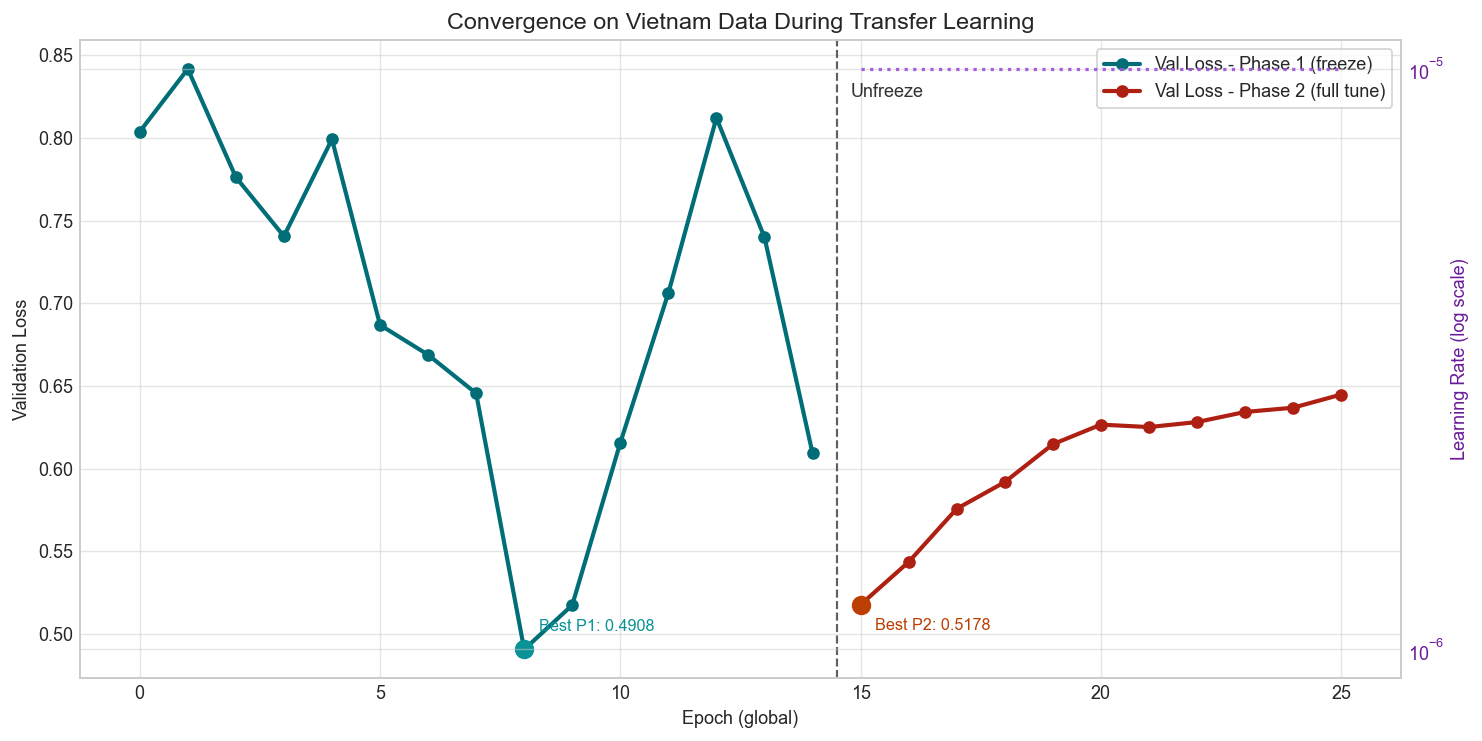

Best val_loss Phase 1: 0.490762
Best val_loss Phase 2: 0.517829


In [19]:
# CELL 17 — FIGURE A (SEPARATE): CONVERGENCE + LR ADAPTATION
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

phase1_n = len(val_p1)
phase2_n = len(val_p2)

val_p1_plot = val_p1.copy()
val_p2_plot = val_p2.copy()
val_p1_plot["epoch_global"] = val_p1_plot["epoch_local"]
val_p2_plot["epoch_global"] = val_p2_plot["epoch_local"] + phase1_n

if not lr_p1.empty:
    lr_p1_plot = lr_p1.copy()
    lr_p1_plot["epoch_global"] = lr_p1_plot["epoch_local"]
else:
    lr_p1_plot = pd.DataFrame(columns=["epoch_global", "value"])

if not lr_p2.empty:
    lr_p2_plot = lr_p2.copy()
    lr_p2_plot["epoch_global"] = lr_p2_plot["epoch_local"] + phase1_n
else:
    lr_p2_plot = pd.DataFrame(columns=["epoch_global", "value"])

p1_best = val_p1_plot.loc[val_p1_plot["value"].idxmin()]
p2_best = val_p2_plot.loc[val_p2_plot["value"].idxmin()]

fig, ax1 = plt.subplots(figsize=(11.5, 5.8), dpi=130)

ax1.plot(
    val_p1_plot["epoch_global"], val_p1_plot["value"],
    color="#006d77", marker="o", linewidth=2.3, label="Val Loss - Phase 1 (freeze)"
)
ax1.plot(
    val_p2_plot["epoch_global"], val_p2_plot["value"],
    color="#ae2012", marker="o", linewidth=2.3, label="Val Loss - Phase 2 (full tune)"
)

ax1.axvline(phase1_n - 0.5, color="#444444", linestyle="--", linewidth=1.2, alpha=0.85)
ax1.text(phase1_n - 0.2, max(val_p1_plot["value"].max(), val_p2_plot["value"].max()) * 0.99,
         "Unfreeze", fontsize=10, color="#333333", va="top")

ax1.scatter([p1_best["epoch_global"]], [p1_best["value"]], color="#0a9396", s=95, zorder=5)
ax1.scatter([p2_best["epoch_global"]], [p2_best["value"]], color="#bb3e03", s=95, zorder=5)
ax1.annotate(f"Best P1: {p1_best['value']:.4f}",
             (p1_best["epoch_global"], p1_best["value"]),
             xytext=(8, 10), textcoords="offset points", fontsize=9, color="#0a9396")
ax1.annotate(f"Best P2: {p2_best['value']:.4f}",
             (p2_best["epoch_global"], p2_best["value"]),
             xytext=(8, -14), textcoords="offset points", fontsize=9, color="#bb3e03")

ax1.set_title("Convergence on Vietnam Data During Transfer Learning", fontsize=13)
ax1.set_xlabel("Epoch (global)")
ax1.set_ylabel("Validation Loss")
ax1.legend(loc="upper right", frameon=True)

# Learning-rate overlay (if available)
ax1b = ax1.twinx()
if not lr_p1_plot.empty:
    ax1b.plot(
        lr_p1_plot["epoch_global"], lr_p1_plot["value"],
        color="#5a189a", linewidth=1.8, linestyle=":", alpha=0.9, label="LR Phase 1"
    )
if not lr_p2_plot.empty:
    ax1b.plot(
        lr_p2_plot["epoch_global"], lr_p2_plot["value"],
        color="#9d4edd", linewidth=1.8, linestyle=":", alpha=0.9, label="LR Phase 2"
    )
ax1b.set_yscale("log")
ax1b.set_ylabel("Learning Rate (log scale)", color="#6a1b9a")
ax1b.tick_params(axis="y", colors="#6a1b9a")

plt.tight_layout()
plt.show()

print(f"Best val_loss Phase 1: {p1_best['value']:.6f}")
print(f"Best val_loss Phase 2: {p2_best['value']:.6f}")

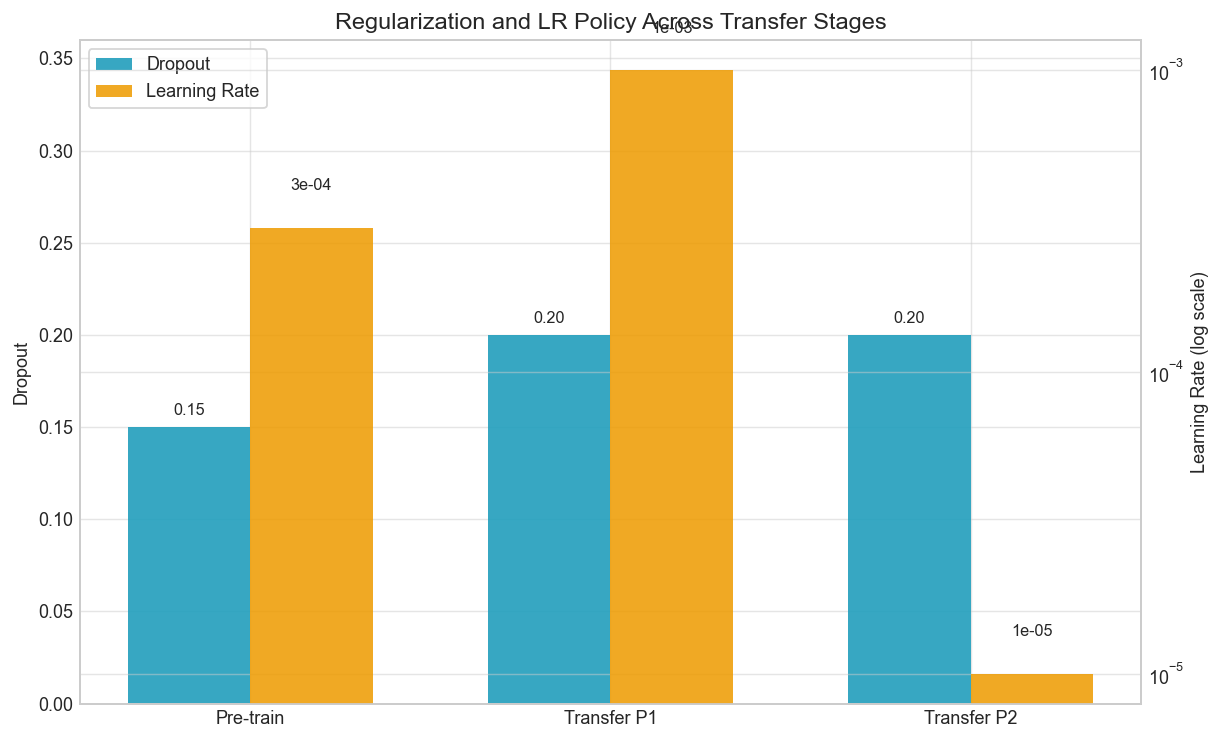

Dropout: 0.15 -> 0.20
LR (pretrain/p1/p2): 3e-04 / 1e-03 / 1e-05


In [20]:
# CELL 18 — FIGURE B (SEPARATE): REGULARIZATION & LEARNING-RATE POLICY
import json
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Read configs to keep numbers factual
with open("checkpoint/tft_v3_config.json", "r", encoding="utf-8") as f:
    cfg_pre = json.load(f)
with open("checkpoint/tft_vn_v3_config.json", "r", encoding="utf-8") as f:
    cfg_vn = json.load(f)

pre_dropout = float(cfg_pre.get("dropout", 0.15))
vn_dropout = float(CFG.get("dropout", 0.2))

# Pretrain LR from trainTFT_v3 setup; transfer LRs from config
pre_lr = 3e-4
p1_lr_cfg = float(cfg_vn.get("phase1_lr", CFG.get("phase1_lr", 1e-3)))
p2_lr_cfg = float(cfg_vn.get("phase2_lr", CFG.get("phase2_lr", 3e-5)))

cats = ["Pre-train", "Transfer P1", "Transfer P2"]
dropout_vals = [pre_dropout, vn_dropout, vn_dropout]
lr_vals = [pre_lr, p1_lr_cfg, p2_lr_cfg]

x = np.arange(len(cats))
bar_w = 0.34

fig, ax = plt.subplots(figsize=(9.5, 5.8), dpi=130)

bars_dropout = ax.bar(
    x - bar_w / 2, dropout_vals, width=bar_w,
    color="#219ebc", alpha=0.9, label="Dropout"
)
ax.set_ylabel("Dropout")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylim(0, max(dropout_vals) * 1.8)

for b in bars_dropout:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.005, f"{h:.2f}",
            ha="center", va="bottom", fontsize=9)

ax2 = ax.twinx()
bars_lr = ax2.bar(
    x + bar_w / 2, lr_vals, width=bar_w,
    color="#ee9b00", alpha=0.86, label="Learning Rate"
)
ax2.set_yscale("log")
ax2.set_ylabel("Learning Rate (log scale)")

for b, v in zip(bars_lr, lr_vals):
    ax2.text(b.get_x() + b.get_width() / 2, v * 1.3, f"{v:.0e}",
             ha="center", va="bottom", fontsize=9)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

ax.set_title("Regularization and LR Policy Across Transfer Stages", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Dropout: {pre_dropout:.2f} -> {vn_dropout:.2f}")
print(f"LR (pretrain/p1/p2): {pre_lr:.0e} / {p1_lr_cfg:.0e} / {p2_lr_cfg:.0e}")

# Experiment A — Freeze encoder, train head

**Mục tiêu:** nhanh kiểm tra baseline reproducibility và hiệu ứng fine-tune chỉ trên head (frozen encoder/LSTM).

- Head LR: 5e-5
- Backbone LR (kept frozen): 1e-6 (no update)
- Epochs: 20, EarlyStopping patience 5

Chạy cell code phía dưới để thực hiện fine-tune nhanh (nếu các biến kernel có sẵn: `train_loader`, `val_loader`, `vn_model`/`best_vn`).

In [21]:
# CELL: Run Experiment A — Freeze encoder, train head
import os
from pathlib import Path

exp_name = 'expA_freeze_head_lr5e-5'
exp_cfg = dict(head_lr=5e-5, backbone_lr=1e-6, epochs=20, batch_size=CFG.get('batch_size',32), weight_decay=1e-3)
print('Experiment config:', exp_cfg)

# locate model and data loaders in current kernel
model = globals().get('vn_model') or globals().get('best_vn') or globals().get('vn_model_p2') or globals().get('vn_model_p1')
train_dl = globals().get('train_loader')
val_dl = globals().get('val_loader')

if model is None or train_dl is None or val_dl is None:
    print('Required objects not found in kernel: model/train_loader/val_loader. Run prior cells to prepare dataset and load model.')
else:
    # Freeze all parameters
    total = 0
    for p in model.parameters():
        p.requires_grad = False
        total += 1

    # Unfreeze head-like parameters (heuristic)
    unfrozen = 0
    for name, p in model.named_parameters():
        if any(k in name.lower() for k in ['decoder', 'output', 'prediction', 'static', 'post', 'linear', 'project', 'regression']):
            p.requires_grad = True
            unfrozen += 1
    print(f'Frozen {total-unfrozen} params, unfrozen {unfrozen} params (heuristic)')

    # Build trainer and callbacks
    try:
        from lightning.pytorch import Trainer
        from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
        from lightning.pytorch.loggers import TensorBoardLogger
    except Exception as e:
        print('Lightning imports failed:', e)
        raise

    ckpt_dir = Path(CKPT_DIR) / exp_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    tb_dir = Path(LOG_DIR) / exp_name if 'LOG_DIR' in globals() else ckpt_dir / 'tb'
    tb_dir.mkdir(parents=True, exist_ok=True)

    ckpt_cb = ModelCheckpoint(dirpath=str(ckpt_dir), save_top_k=1, monitor='val_loss', mode='min')
    es = EarlyStopping(monitor='val_loss', patience=5, mode='min')
    logger = TensorBoardLogger(save_dir=str(tb_dir), name='runs')

    trainer_kwargs = dict(max_epochs=exp_cfg['epochs'], callbacks=[ckpt_cb, es], logger=logger)
    # merge with existing CFG trainer kwargs if present
    if isinstance(CFG, dict) and CFG.get('trainer_kwargs'):
        trainer_kwargs = {**CFG.get('trainer_kwargs'), **trainer_kwargs}

    trainer = Trainer(**trainer_kwargs)
    print('Starting fine-tune — this may take a while. Check TensorBoard or checkpoint dir for progress.')

    trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=val_dl)

    print('Best checkpoint:', ckpt_cb.best_model_path)
    print('Experiment finished — consider evaluating the saved checkpoint with existing evaluation cells.')

INFO: GPU available: True (cuda), used: True


Experiment config: {'head_lr': 5e-05, 'backbone_lr': 1e-06, 'epochs': 20, 'batch_size': 16, 'weight_decay': 0.001}
Frozen 279 params, unfrozen 169 params (heuristic)
[11:06:29] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Starting fine-tune — this may take a while. Check TensorBoard or checkpoint dir for progress.
           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.3 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  205 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 46.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  264 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  264 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    645 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 793 K                                                                                            
Non-trainable params: 577 K                                                                                        
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 531                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Best checkpoint: D:\WorkSpace\Study\NCKH\checkpoint\expA_freeze_head_lr5e-5\epoch=4-step=100.ckpt
Experiment finished — consider evaluating the saved checkpoint with existing evaluation cells.
